## Load in Test Case & Run Power Flow

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
out_dir = project_dir / "out"

In [40]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools.eval_measures import rmse
import andes


andes.config_logger(stream_level=30)

In [42]:
# base case file
case_path = test_case_dir / "regf2_testbench.xlsx"

## Metrics/Analysis

### H Calculation

In [ ]:
def calculate_inertia_timeseries(ss, power_tms, p_ref, rocof_tms, window=20):
    deltaP = power_tms.subtract(p_ref)
    deltaF = ss.TDS.get_timeseries(ss.BusROCOF.f) - 1

    tds_df = pd.concat([deltaP, deltaF, rocof_tms], axis=1)
    tds_df.columns = ["Delta P (pu)", "Delta F (pu)", "RoCoF (pu)"]

    time_invalid = 1 + window * STEP_TIME # will produce invalid results w/in the first window

    X = sm.add_constant(tds_df[['RoCoF (pu)', 'Delta F (pu)']])  # add Δf as 2nd predictor
    model = RollingOLS(tds_df['Delta P (pu)'], X, window=window)
    res = model.fit()

    H_t_raw = -res.params['RoCoF (pu)'] / 2 
    D_t_raw = res.params['Delta F (pu)']

    tds_df.loc[:,"H (s)"] = H_t_raw[time_invalid:]
    tds_df.loc[:,"D"] = D_t_raw[time_invalid:]

    return tds_df

In [59]:
def calculate_inertia_rmse(ss, tds_df, window=20):
    H_gfm = ss.REGF2.get("mf", 1)
    H_t = tds_df["H (s)"]
    time_invalid = 1 + window * STEP_TIME # will produce invalid results w/in the first window

    predicted = np.asarray(H_t[time_invalid:])
    actual = np.full(predicted.size, H_gfm)
    error = rmse(actual, predicted)
    return error

In [46]:
def calc_settling_time(df, var, threshold=0.05):
    y = np.asarray(df.loc[:,var])
    t = df.index

    steady_state = np.average(y[-10:-1]) # average last 10 vals as steady-state
    allowed_error = threshold * abs(steady_state)
    
    error = np.abs(y - steady_state)
    
    # find all indices where the error exceeds the threshold
    outside_band_indices = np.where(error > allowed_error)[0]
    
    if len(outside_band_indices) == 0:
        return t[0] 
        
    last_outside_index = outside_band_indices[-1]
    
    # ensure we don't overflow the array boundary
    if last_outside_index < len(t) - 1:
        return t[last_outside_index + 1]
    else:
        return t[last_outside_index]

## Record Metrics

In [67]:
def calculate_metrics(ss, metrics_df):
    tr = ss.REGF2.get("Tr", 1)
    window = 20 # Baruzzi et al. used 1 window = 20 steps

    # get needed timeseries
    freq_timeseries = ss.TDS.get_timeseries(ss.BusFreq.f).loc[:,"BusFreq_1"]
    rocof_timeseries = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
    power_timeseries = ss.TDS.get_timeseries(ss.REGF2.Pe)

    # initial metrics calculation
    peak_inertial_power = np.max(power_timeseries) 
    max_rocof = np.max(np.abs(rocof_timeseries))
    freq_nadir = np.min(freq_timeseries)
    p_avail = ss.REGF2.get("Pmax", 1) # pu
    p_ref = ss.PV.get("p0", 1) # pu

    # calculate inertia metrics
    tds_df = calculate_inertia_timeseries(ss, power_timeseries, p_ref, rocof_timeseries, window=window)
    error = calculate_inertia_rmse(ss, tds_df, window=window)
    settling_time = calc_settling_time(tds_df, "H (s)")

    # add to metrics dataframe
    row = [tr, p_ref, peak_inertial_power, p_avail, error, max_rocof, freq_nadir, settling_time]
    metrics_df.loc[len(metrics_df)] = row


In [ ]:
settling_time = calc_settling_time(tds_df, "H (s)")

row = [tr, p_ref, peak_inertial_power, p_avail, error, max_rocof, freq_nadir, settling_time]
print(row)
metrics_df.loc[len(metrics_df)] = row
metrics_df

## Run TDS & Initial Results

In [ ]:
# anything w/o units is in p.u. 
metrics = pd.DataFrame({
    "Tr (s)": [], 
    "Pref": [],
    "Peak Inertial Power": [],
    "Power Available":[],
    "H_RMSE (s)": [],
    "Max RoCoF":[],
    "Nadir":[],
    "Settling Time (s)":[]
})

In [79]:
STEP_TIME = 0.01 # 10 ms
Tr_vals = np.linspace(0, 0.1, 25)
Tr_vals

array([0.        , 0.00416667, 0.00833333, 0.0125    , 0.01666667,
       0.02083333, 0.025     , 0.02916667, 0.03333333, 0.0375    ,
       0.04166667, 0.04583333, 0.05      , 0.05416667, 0.05833333,
       0.0625    , 0.06666667, 0.07083333, 0.075     , 0.07916667,
       0.08333333, 0.0875    , 0.09166667, 0.09583333, 0.1       ])

In [80]:
# TDS started to not converge at tr = 0.006875
metrics = metrics.iloc[0:0]

for tr in Tr_vals:
    # load a new case
    base_case = andes.get_case(case_path)
    ss = andes.load(base_case, setup=False)

    # change Tr
    ss.REGF2.set('Tr', 1, tr) # independent variable
    print(f"Running TDS for Tr = {ss.REGF2.Tr.v}...")

    # TDS
    ss.setup()
    ss.config.warn_abnormal = 1
    ss.PFlow.run()

    ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
    ss.TDS.config.fixt = 1 # fixed step size
    ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

    ss.TDS.config.no_tqdm = 1
    ss.TDS.config.criteria = 1
    ss.TDS.run()

    # metrics
    calculate_metrics(ss, metrics)

print("All done!")

Running TDS for Tr = [np.float64(0.0)]...
1.2
Running TDS for Tr = [np.float64(0.004166666666666667)]...
1.2
Running TDS for Tr = [np.float64(0.008333333333333333)]...
1.2
Running TDS for Tr = [np.float64(0.0125)]...
1.2
Running TDS for Tr = [np.float64(0.016666666666666666)]...
1.2
Running TDS for Tr = [np.float64(0.020833333333333332)]...
1.2
Running TDS for Tr = [np.float64(0.025)]...
1.2
Running TDS for Tr = [np.float64(0.029166666666666667)]...
1.2
Running TDS for Tr = [np.float64(0.03333333333333333)]...
1.2
Running TDS for Tr = [np.float64(0.0375)]...
1.2
Running TDS for Tr = [np.float64(0.041666666666666664)]...
1.2
Running TDS for Tr = [np.float64(0.04583333333333333)]...
1.2
Running TDS for Tr = [np.float64(0.05)]...
1.2
Running TDS for Tr = [np.float64(0.05416666666666667)]...
1.2
Running TDS for Tr = [np.float64(0.058333333333333334)]...
1.2
Running TDS for Tr = [np.float64(0.0625)]...
1.2
Running TDS for Tr = [np.float64(0.06666666666666667)]...


Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=9.3893 s.


1.2
Running TDS for Tr = [np.float64(0.07083333333333333)]...


Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=8.8919 s.


1.2
Running TDS for Tr = [np.float64(0.075)]...


...

Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=3.9335 s.


1.2
Running TDS for Tr = [np.float64(0.09583333333333333)]...


Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=7.7642 s.


1.2
Running TDS for Tr = [np.float64(0.1)]...
1.2
All done!


Time step reduced to zero. Convergence is not likely.
Simulation terminated at t=7.6157 s.


In [82]:
metrics

,Tr (s),Pref,Peak Inertial Power,Power Available,H_RMSE (s),Max RoCoF,Nadir,Settling Time (s)
0,0.000000,0.2,0.275852,1.0,0.732005,7.501773e-03,0.997734,3.833333
1,0.004167,0.2,0.279561,1.0,0.804158,7.647149e-03,0.997696,3.853533
2,0.008333,0.2,0.283749,1.0,0.926042,7.793669e-03,0.997646,4.500000
3,0.012500,0.2,0.288193,1.0,1.123562,7.952676e-03,0.997589,4.533333
4,0.016667,0.2,0.292664,1.0,1.430513,8.089525e-03,0.997526,5.200000
5,0.020833,0.2,0.297000,1.0,1.917469,8.227937e-03,0.997462,5.553533
6,0.025000,0.2,0.301112,1.0,2.847574,8.343599e-03,0.997402,6.296867
7,0.029167,0.2,0.305035,1.0,6.273456,8.462265e-03,0.997341,6.476867
8,0.033333,0.2,0.309129,1.0,9.662753,8.558028e-03,0.997286,6.576867
9,0.037500,0.2,0.312957,1.0,7.168349,8.661290e-03,0.997229,9.920200


## Visualizaton

In [103]:
metrics.set_index("Tr (s)")
convergence_failed = 0.06666666666666667 - 0.1/25 # Tr value where TDS starts to fail to converge

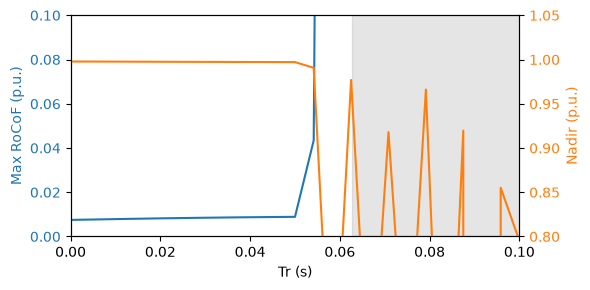

In [124]:
x_tr = metrics["Tr (s)"]
y_1 = metrics["Max RoCoF"]
y_2 = metrics["Nadir"]

fig, ax1 = plt.subplots(figsize=(6, 3))

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Max RoCoF (p.u.)', color=color)
ax1.plot(x_tr, y_1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Nadir (p.u.)', color=color)
ax2.plot(x_tr, y_2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax2.set_ylim(0.8, 1.05)
ax2.set_xlim(0, 0.1)
ax2.axvspan(convergence_failed, 0.2, color='gray', alpha=0.2)

ax1.set_ylim(0.0, 0.1)

fig.tight_layout()  # Prevents right-hand label from getting clipped
plt.show()

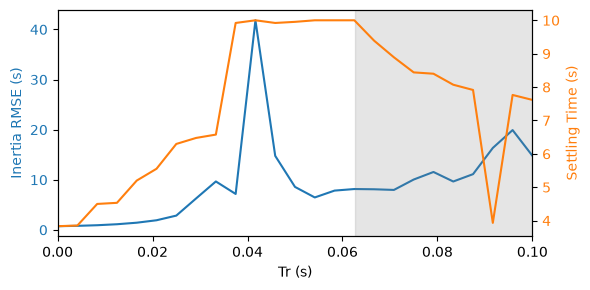

In [123]:
x_tr = metrics["Tr (s)"]
y_rmse = metrics["H_RMSE (s)"]
y_settle = metrics["Settling Time (s)"]

fig, ax1 = plt.subplots(figsize=(6, 3))

# First Y-Axis (Left side)
color = 'tab:blue'
ax1.set_xlabel('Tr (s)')
ax1.set_ylabel('Inertia RMSE (s)', color=color)
ax1.plot(x_tr, y_rmse, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Second Y-Axis (Right side)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Settling Time (s)', color=color)
ax2.plot(x_tr, y_settle, color=color)
ax2.tick_params(axis='y', labelcolor=color)

#ax2.set_ylim(0.9, 1)
ax2.set_xlim(0, 0.1)
ax2.axvspan(convergence_failed, 0.2, color='gray', alpha=0.2)

fig.tight_layout()  # Prevents right-hand label from getting clipped
plt.show()